In [1]:
import torch
import pandas as pd
import numpy as np
import re
import random
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    BartTokenizerFast,
    BartForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
    GenerationConfig
)
from peft import LoraConfig, get_peft_model, TaskType
import evaluate
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

CUDA Available: True
Device: NVIDIA GeForce RTX 2050
VRAM: 4.00 GB


In [2]:
df = pd.read_csv("newDataset1.csv")
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Loaded {len(df)} rows")

df['concept_len'] = df['Concept'].apply(lambda x: len(x.split()))
df['notes_len'] = df['Notes'].apply(lambda x: len(x.split()))

print(f"\nInput (Concept) length stats:")
print(f"  Mean: {df['concept_len'].mean():.1f} | Median: {df['concept_len'].median():.0f}")
print(f"  Min: {df['concept_len'].min():.0f} | Max: {df['concept_len'].max():.0f}")
print(f"  95th percentile: {np.percentile(df['concept_len'], 95):.0f}")
print(f"  99th percentile: {np.percentile(df['concept_len'], 99):.0f}")

print(f"\nOutput (Notes) length stats:")
print(f"  Mean: {df['notes_len'].mean():.1f} | Median: {df['notes_len'].median():.0f}")
print(f"  Min: {df['notes_len'].min():.0f} | Max: {df['notes_len'].max():.0f}")
print(f"  95th percentile: {np.percentile(df['notes_len'], 95):.0f}")
print(f"  99th percentile: {np.percentile(df['notes_len'], 99):.0f}")

# DYNAMIC LENGTH CALCULATION
# Use 99th percentile + buffer for safety
MAX_INPUT_LENGTH = min(int(np.percentile(df['concept_len'], 99) * 1.3), 512)
MAX_TARGET_LENGTH = min(int(np.percentile(df['notes_len'], 99) * 1.3), 256)
MIN_TARGET_LENGTH = 2

print(f"\nDynamic Configuration:")
print(f"  MAX_INPUT_LENGTH: {MAX_INPUT_LENGTH}")
print(f"  MAX_TARGET_LENGTH: {MAX_TARGET_LENGTH}")
print(f"  MIN_TARGET_LENGTH: {MIN_TARGET_LENGTH}")

replacements = {
    r'\b(increases?|increased|increasing|rises?|grows?)\b': '↑',
    r'\b(decreases?|decreased|decreasing|falls?|shrinks?)\b': '↓',
    r'\b(proportional to|proportional)\b': '∝',
    r'\b(leads to|results in|causes)\b': '→',
    r'\b(equals?|is equal to)\b': '='
}

for pattern, symbol in replacements.items():
    df['Notes'] = df['Notes'].apply(
        lambda x: re.sub(pattern, symbol, str(x), flags=re.IGNORECASE)
    )


all_text = ' '.join(df['Notes'].tolist())
symbols_found = [sym for _, sym in replacements.items() if sym in all_text]
print(f"\nSymbols found in dataset: {symbols_found}")

initial_count = len(df)
df = df.drop_duplicates(subset=['Concept'])
print(f"Removed {initial_count - len(df)} duplicates, {len(df)} remaining")

df = df[df['notes_len'] >= 2]
print(f"After quality filter: {len(df)} rows")

Loaded 1216 rows

Input (Concept) length stats:
  Mean: 21.6 | Median: 22
  Min: 13 | Max: 34
  95th percentile: 27
  99th percentile: 30

Output (Notes) length stats:
  Mean: 15.1 | Median: 15
  Min: 5 | Max: 30
  95th percentile: 20
  99th percentile: 23

Dynamic Configuration:
  MAX_INPUT_LENGTH: 39
  MAX_TARGET_LENGTH: 29
  MIN_TARGET_LENGTH: 2

Symbols found in dataset: ['↑', '↓', '∝', '→', '=']
Removed 0 duplicates, 1216 remaining
After quality filter: 1216 rows


In [3]:
def augment_text(text, prob=0.85):
    """Light augmentation to improve model robustness"""
    if random.random() > prob:
        return text
    
    words = text.split()
    if len(words) < 6:
        return text
    
    synonyms = {
        'is': ['represents', 'constitutes'],
        'are': ['represent', 'constitute'],
        'has': ['possesses', 'contains'],
        'have': ['possess', 'contain'],
        'shows': ['demonstrates', 'indicates'],
        'uses': ['utilizes', 'employs'],
    }
    
    new_words = []
    for word in words:
        if word.lower() in synonyms and random.random() < 0.3:
            new_words.append(random.choice(synonyms[word.lower()]))
        else:
            new_words.append(word)
    
    return ' '.join(new_words)


In [4]:
model_id = "./bart-base-local"
tokenizer = BartTokenizerFast.from_pretrained(model_id)
model = BartForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print(f"Model loaded: {model_id}")
print(f"Vocabulary size: {len(tokenizer)}")
print(f"Model on device: {next(model.parameters()).device}")

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Model loaded: ./bart-base-local
Vocabulary size: 50265
Model on device: cuda:0


In [5]:
dataset = Dataset.from_pandas(df) 
dataset = dataset.train_test_split(test_size=0.1, seed=42)

train_df = dataset["train"].to_pandas()
augmented_rows = []
for _, row in train_df.iterrows():
    augmented_rows.append({'Concept': row['Concept'], 'Notes': row['Notes']})
    augmented_rows.append({'Concept': augment_text(row['Concept']), 'Notes': row['Notes']})

train_df_augmented = pd.DataFrame(augmented_rows).drop_duplicates(subset=['Concept'])
print(f"Training set augmented: {len(train_df_augmented)} rows")

dataset["train"] = Dataset.from_pandas(train_df_augmented)

def preprocess(batch):
    model_inputs = tokenizer(batch["Concept"], max_length=MAX_INPUT_LENGTH, truncation=True)
    labels = tokenizer(text_target=batch["Notes"], max_length=MAX_TARGET_LENGTH, truncation=True)
    
    labels["input_ids"] = [
        [(token if token != tokenizer.pad_token_id else -100) for token in label]
        for label in labels["input_ids"]
    ]
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = dataset["train"].map(preprocess, batched=True, remove_columns=dataset["train"].column_names)
tokenized_val = dataset["test"].map(preprocess, batched=True, remove_columns=dataset["test"].column_names)

print(f"Train: {len(tokenized_train)} | Validation: {len(tokenized_val)}")

Training set augmented: 1142 rows


Map:   0%|          | 0/1142 [00:00<?, ? examples/s]

Map:   0%|          | 0/122 [00:00<?, ? examples/s]

Train: 1142 | Validation: 122


In [6]:
rouge = evaluate.load("rouge")
print("✓ ROUGE loaded")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    
    # Decode predictions
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_preds = [pred.strip() for pred in decoded_preds]
    
    # Decode labels
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_labels = [label.strip() for label in decoded_labels]
    
    # ROUGE scores
    rouge_result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )
    
    # Length metrics
    pred_lengths = [len(pred.split()) for pred in decoded_preds]
    label_lengths = [len(label.split()) for label in decoded_labels]

    # Compression ratio
    compressions = [pl/ll if ll > 0 else 0 for pl, ll in zip(pred_lengths, label_lengths)]
    
    result = {
        "rouge1": round(rouge_result["rouge1"], 4),
        "rouge2": round(rouge_result["rouge2"], 4),
        "rougeL": round(rouge_result["rougeL"], 4),
        "rougeLsum": round(rouge_result["rougeLsum"], 4),
        "avg_pred_len": round(np.mean(pred_lengths), 1),
        "avg_compression": round(np.mean(compressions), 3),
    }
    
    return result

✓ ROUGE loaded


In [7]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 884,736 || all params: 140,305,152 || trainable%: 0.6306


In [8]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer, 
    model=model, 
    label_pad_token_id=-100,
    padding=True
)

generation_config = GenerationConfig(
    max_length=150,
    min_length=MIN_TARGET_LENGTH,
    num_beams=5,
    length_penalty=1.0,
    early_stopping=True,
    
    repetition_penalty=1.1,
)

training_args = Seq2SeqTrainingArguments(
    output_dir="./notes_Gravity",
    
    # Batch configuration
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    
    # Learning rate & scheduling
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=0.1,
    label_smoothing_factor=0.1,
    weight_decay=0.001,
    
    optim="adamw_torch",
    
    # Training duration
    num_train_epochs=20,
    
    # Evaluation strategy
    eval_strategy="epoch",
    save_strategy="epoch",
    predict_with_generate=True,
    generation_config=generation_config,
    
    # Mixed precision
    fp16=torch.cuda.is_available(),
    
    # Logging
    logging_steps=20,
    logging_first_step=True,
    save_total_limit=3,
    
    # Best model selection
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    
    # Performance
    dataloader_num_workers=2,
    report_to="none",
    remove_unused_columns=False,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
)

# Train
train_result = trainer.train()

# Save best model
trainer.save_model("./notes_Gravity")
tokenizer.save_pretrained("./notes_Gravity")
print("\n✓ Model saved to ./notes_Gravity")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Avg Pred Len,Avg Compression
1,22.109067,4.543798,0.454100,0.212100,0.423500,0.423100,11.500000,0.849000
2,16.639182,3.860695,0.499000,0.245300,0.468100,0.467600,11.000000,0.808000
3,15.610423,3.799276,0.506400,0.259000,0.477000,0.476400,11.000000,0.807000
4,15.200804,3.610564,0.520700,0.267700,0.492400,0.492000,10.900000,0.805000
5,14.967433,3.575067,0.518100,0.264700,0.489100,0.488200,10.800000,0.792000
6,14.911192,3.522931,0.533500,0.276400,0.499300,0.498800,10.800000,0.792000
7,14.721674,3.515273,0.538200,0.285700,0.504600,0.504100,10.800000,0.791000
8,14.507504,3.502327,0.539300,0.284400,0.508400,0.507700,10.800000,0.796000
9,14.328693,3.450546,0.536400,0.288700,0.504900,0.504100,10.700000,0.787000
10,13.832484,3.463632,0.542800,0.291400,0.512600,0.512600,10.800000,0.791000


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer RobertaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



✓ Model saved to ./notes_Gravity


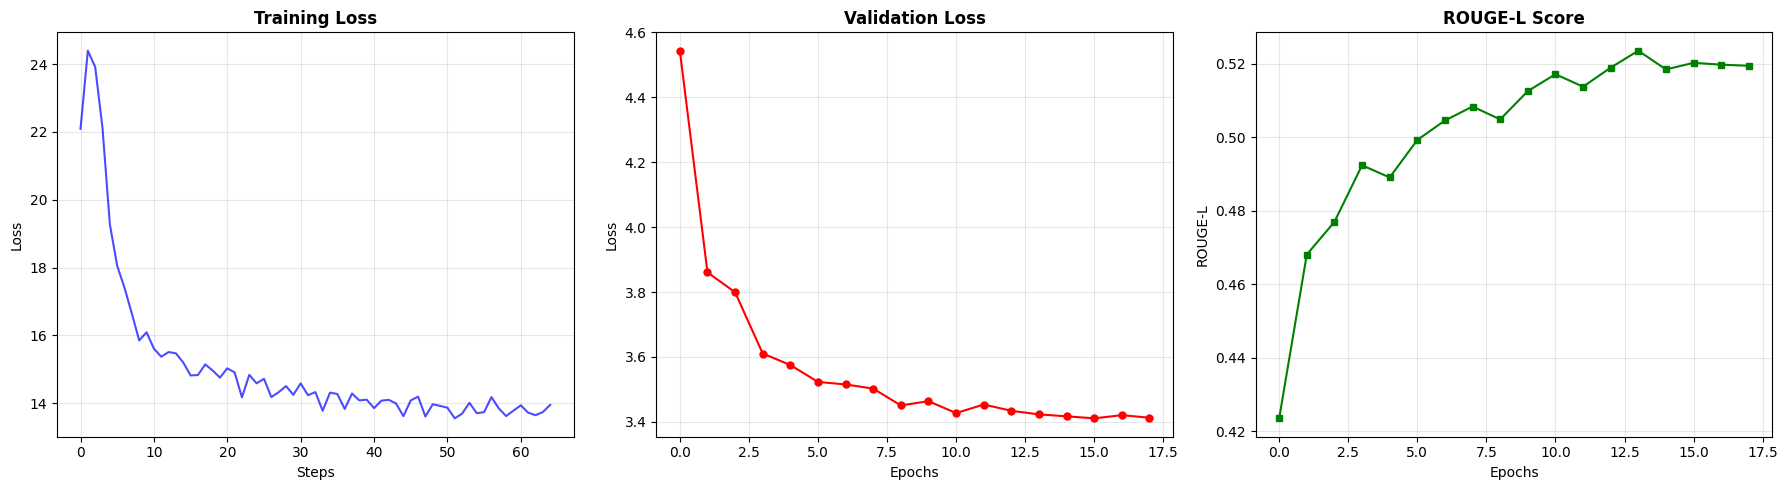

In [9]:
history = trainer.state.log_history

train_losses = [log['loss'] for log in history if 'loss' in log and 'eval_loss' not in log]
eval_losses = [log['eval_loss'] for log in history if 'eval_loss' in log]
eval_rouge = [log['eval_rougeL'] for log in history if 'eval_rougeL' in log]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training Loss
axes[0].plot(train_losses, color='blue', alpha=0.7, linewidth=1.5)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# Validation Loss
if eval_losses:
    axes[1].plot(eval_losses, color='red', marker='o', markersize=5, linewidth=1.5)
    axes[1].set_title('Validation Loss', fontweight='bold')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True, alpha=0.3)

# ROUGE-L
if eval_rouge:
    axes[2].plot(eval_rouge, color='green', marker='s', markersize=5, linewidth=1.5)
    axes[2].set_title('ROUGE-L Score', fontweight='bold')
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('ROUGE-L')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_progress.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
def generate_smart_note(text):
    model.eval()
    
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256).to("cuda")
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_TARGET_LENGTH,     
            min_new_tokens=MIN_TARGET_LENGTH,       
            num_beams=5,             
            length_penalty=1.0,      
            early_stopping=True,     
            repetition_penalty=1.1   
            
        )
        
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


# Test cases
test_samples = [
    # Simple
    "Duke Metternich was a French king.",
    
    # Complex with multiple concepts
    "Aristotle's syllogism is a form of deductive reasoning consisting of a major premise, minor premise, and conclusion.",
    
    # Very complex - should NOT truncate
    "The post-colonial state: weak institutions, arbitrary borders, neo-patrimonial rule, resource curse, ethnic fragmentation; Mamdani: citizen vs. subject distinction from colonial rule.",
    
    # With nested structures
    "Bioethics principles (Beauchamp-Childress): autonomy (respect patient choice) + beneficence (do good) + non-maleficence (avoid harm) + justice (fair distribution); principlism.",
    
    # Philosophical
    "Wittgenstein's language games: meaning = use; different language games have different rules; family resemblance (no single essence to concepts); private language argument against solipsism.",
    
    # Scientific
    "Photosynthesis converts sunlight into chemical energy through chlorophyll in plant cells, producing glucose and oxygen.",
]

print("\nGENERATION TESTS:")
print("-" * 70)

for i, sample in enumerate(test_samples, 1):
    note = generate_smart_note(sample)
    
    input_words = len(sample.split())
    note_words = len(note.split())
    compression = note_words / input_words if input_words > 0 else 0

    print(f"\n{i}. Input ({input_words} words): {sample[:100]}...")
    print(f"   Note ({note_words} words): {note}")
    print(f"   Compression: {compression:.2f}")


GENERATION TESTS:
----------------------------------------------------------------------

1. Input (6 words): Duke Metternich was a French king....
   Note (4 words): Duke Metternich: French king
   Compression: 0.67

2. Input (17 words): Aristotle's syllogism is a form of deductive reasoning consisting of a major premise, minor premise,...
   Note (9 words): Aristotle syllogism: major premise + minor premise + conclusion
   Compression: 0.53

3. Input (21 words): The post-colonial state: weak institutions, arbitrary borders, neo-patrimonial rule, resource curse,...
   Note (13 words): post-colonial state: weak institutions, arbitrary borders, neo-patrimonial rule, resource curse, ethnic fragmentation; Mamdani
   Compression: 0.62

4. Input (20 words): Bioethics principles (Beauchamp-Childress): autonomy (respect patient choice) + beneficence (do good...
   Note (13 words): Bioethics: autonomy (respect patient choice) + beneficence (do good) + non-maleficence (avoid harm
   Compressio

In [11]:
import json

deploy_config = {
    'model_type': 'facebook/bart-base',
    'max_input_length': MAX_INPUT_LENGTH,
    'max_target_length': MAX_TARGET_LENGTH,
    'min_target_length': MIN_TARGET_LENGTH,
    'generation_params': {
        'num_beams': 5,
        'length_penalty': 1.0,
        'early_stopping': True,
        'repetition_penalty': 1.1,
    
    },
    'training_samples': len(tokenized_train),
    'validation_samples': len(tokenized_val),
    'best_rougeL': max(eval_rouge) if eval_rouge else None,
}

with open('./notes_Gravity/deploy_config.json', 'w') as f:
    json.dump(deploy_config, f, indent=2)

print("✓ Configuration saved")

print(f"Best ROUGE-L: {deploy_config['best_rougeL']}")
print(f"Model ready for inference at: ./notes_Gravity")

✓ Configuration saved
Best ROUGE-L: 0.5236
Model ready for inference at: ./notes_Gravity


In [12]:
from huggingface_hub import notebook_login, HfApi

In [ ]:
repo_id = "Priyanshu-i/NoteFormer-BART"

print(f"Pushing adapter weights to {repo_id}...")
model.push_to_hub(repo_id, private=True)

print(f"Pushing tokenizer to {repo_id}...")
tokenizer.push_to_hub(repo_id, private=True)

print(f"Pushing custom deployment config...")
api = HfApi()
api.upload_file(
    path_or_fileobj="./notes_Gravity/deploy_config.json",
    path_in_repo="deploy_config.json",                            
    repo_id=repo_id,
    repo_type="model",
)

print("✅ Everything is safely backed up to the cloud!")

Pushing adapter weights to Priyanshu-i/NotesGravity...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Pushing tokenizer to Priyanshu-i/NotesGravity...


README.md: 0.00B [00:00, ?B/s]

Pushing custom deployment config...
✅ Everything is safely backed up to the cloud!


In [14]:
sample_text = "Aristotle's syllogism is a form of deductive reasoning consisting of a major premise, minor premise, and conclusion."
print("\nINPUT:", sample_text)
print("TARGET NOTE:", generate_smart_note(sample_text))


INPUT: Aristotle's syllogism is a form of deductive reasoning consisting of a major premise, minor premise, and conclusion.
TARGET NOTE: Aristotle syllogism: major premise + minor premise + conclusion


In [15]:
test_inputs = [
    # Physics
    "Heisenberg's uncertainty principle states that one cannot simultaneously know the exact position and momentum of a particle.",
    "The second law of thermodynamics asserts that entropy of an isolated system always increases over time.",
    
    # Chemistry
    "Ionic bonds form through the electrostatic attraction between positively and negatively charged ions.",
    "Catalysts increase the rate of chemical reactions by lowering the activation energy without being consumed.",
    
    # Biology
    "Enzymes are biological catalysts that speed up metabolic reactions by binding to substrates.",
    "Natural selection drives evolution by favoring traits that improve survival and reproduction.",
    
    # Computer Science
    "A stack data structure follows the Last In, First Out (LIFO) principle for element access.",
    "Hash functions map input data of arbitrary size to fixed-size values, often used in cryptography.",
    
    # Mathematics
    "The Fundamental Theorem of Calculus links differentiation and integration, showing they are inverse processes.",
    "Matrix multiplication is associative but not commutative, meaning order matters in the operation.",
    
    # Statistics / Data Science
    "The central limit theorem states that the distribution of sample means approaches normality as sample size increases.",
    "Correlation measures the strength and direction of a linear relationship between two variables.",
    
    # History / Social Science
    "The Cold War was a geopolitical struggle between the United States and the Soviet Union after World War II.",
    "Feudalism was a medieval European system where land was exchanged for military service and loyalty.",
    
    # Philosophy / Logic
    "Aristotle's syllogism is a form of deductive reasoning consisting of a major premise, minor premise, and conclusion.",
    "Utilitarianism is an ethical theory that promotes actions maximizing happiness and minimizing suffering.",
    
    # Engineering / Applied Science
    "Ohm's law states that voltage across a conductor is proportional to current times resistance.",
    "Fourier transforms decompose signals into their constituent frequencies for analysis.",
    
    # Economics
    "Supply and demand determine market equilibrium, where quantity supplied equals quantity demanded.",
    "Inflation refers to the sustained increase in the general price level of goods and services."
]


results = []

for i, concept in enumerate(test_inputs, 1):

    note = generate_smart_note(concept)

    input_words = len(concept.split())
    note_words = len(note.split())

    compression = (
        note_words / input_words
        if input_words > 0 else 0
    )

    print(f"\n{'='*70}")
    print(f"Test Case {i}")
    print(f"{'='*70}")

    print(f"INPUT ({input_words} words):")
    print(concept)

    print(f"\nGENERATED NOTE ({note_words} words):")
    print(note)

    print(f"\nCompression Ratio: {compression:.2f}")



Test Case 1
INPUT (17 words):
Heisenberg's uncertainty principle states that one cannot simultaneously know the exact position and momentum of a particle.

GENERATED NOTE (11 words):
Heisenberg uncertainty: cannot simultaneously know exact position and momentum of particle

Compression Ratio: 0.65

Test Case 2
INPUT (16 words):
The second law of thermodynamics asserts that entropy of an isolated system always increases over time.

GENERATED NOTE (8 words):
second law: isolated system always increases over time

Compression Ratio: 0.50

Test Case 3
INPUT (13 words):
Ionic bonds form through the electrostatic attraction between positively and negatively charged ions.

GENERATED NOTE (11 words):
Ionic bonds → electrostatic attraction between positively and negatively charged ions

Compression Ratio: 0.85

Test Case 4
INPUT (15 words):
Catalysts increase the rate of chemical reactions by lowering the activation energy without being consumed.

GENERATED NOTE (15 words):
catalysts → ↑ rate 

In [16]:
def generate_smart_note(text):
    model.eval()
    
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256).to("cuda")
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=150,      
            min_new_tokens=MIN_TARGET_LENGTH,
            num_beams=5,             
            length_penalty=1.0,      
            early_stopping=True,     
            repetition_penalty=1.1   
        )
        
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [17]:
import torch
from transformers import BartTokenizerFast, BartForConditionalGeneration
from peft import PeftModel

merged_repo_id = "Priyanshu-i/NotesGravity-Merged" 

print("3. Merging weights permanently (This takes a moment)...")
model = model.merge_and_unload()

print(f"4. Pushing merged model to {merged_repo_id}...")
model.push_to_hub(merged_repo_id, private=True)
tokenizer.push_to_hub(merged_repo_id, private=True)

print("Merged model successfully uploaded!")

3. Merging weights permanently (This takes a moment)...
4. Pushing merged model to Priyanshu-i/NotesGravity-Merged...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Merged model successfully uploaded!


In [18]:
def generateNote(text):
    model.eval()
    input = tokenizer(text, return_tensors="pt").to("cuda")
    # print(input)
    with torch.no_grad():
        output = model.generate(
            **input,
            max_new_tokens=500,      
            min_new_tokens=2,
            num_beams=5,             
            length_penalty=1.0,      
            early_stopping=True,     
            repetition_penalty=1.1  
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)

In [19]:
generateNote("""React is a powerful and flexible library that has transformed the way we
build modern web applications. Its component-based architecture,
combined with tools like the Virtual DOM and hooks, allows developers to
create interactive and efficient user interfaces. When paired with
TypeScript, React offers an even more robust development experience,
helping to catch errors early and maintain clean, scalable code. Whether
you're just getting started with web development or looking to level up your
skills, learning React with TypeScript is a valuable investment for building
modern, dynamic applications.""")

'React: powerful and flexible library → building modern web applications. Component-based architecture (combined with tools like Virtual DOM) → efficient user interfaces'

In [20]:
generateNote("""
While JSX and TSX are syntactically similar, the main difference lies in the
additional type safety that TypeScript brings to TSX. In projects where
TypeScript is used, TSX ensures that your component props, state, and
event handlers adhere to the types you’ve defined.
JSX is used in plain JavaScript-based React projects, and it doesn’t provide
static typing.
TSX is used in TypeScript-based React projects and enforces static typing,
ensuring that you catch errors early in development.
""")

'JSX: syntactically similar; TSX: non-additional type safety; TypeScript = TSX'

In [22]:
tests = df.sample(n = 5)

for idx, row in tests.iterrows():
    print(f'Input = {row.iloc[0]}')
    print(f'Output = {generateNote(row.iloc[0])}')
    print(f'Expected = {row.iloc[1]}')
    print()
    

Input = Gini coefficient measures income inequality: 0 = perfect equality, 1 = perfect inequality; used to compare distributions across countries.
Output = Gini coefficient: 0 = perfect equality, 1 = perfect inequality; compare distributions across countries
Expected = Gini: 0 = perfect equality, 1 = perfect inequality; measures income distribution

Input = The narrator vs. implied author: implied author = image of author constructed from text; narrator = text's voice (may differ from author); narratee = text's imagined audience.
Output = v narrator vs. implied author: implied author = image constructed from text; narrator = text's voice (may differ from author); narratee = imagined audience
Expected = narrator ≠ implied author; implied author = textual image of author; narratee = imagined audience; Wayne Booth's distinction

Input = Rising house prices increase household collateral values, enabling more borrowing, which funds consumption, further raising prices in a self-reinforcing c